In [49]:
#TASK 1: Data Collection & Understanding


In [3]:
import pandas as pd

data = pd.read_csv("Titanic-Dataset.csv", encoding='latin1')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Structure
print("Shape:", data.shape)
print("Columns:", data.columns)
data.info()

Shape: (891, 12)
Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [51]:
#TASK 2: Data Cleaning & Feature Engineering

In [13]:
# Remove extra spaces and standardize column names
data.columns = data.columns.str.strip()

print(data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
# Fill Age with median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Fill Embarked with mode
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Drop Cabin (too many missing values)
if 'Cabin' in data.columns:
    data.drop('Cabin', axis=1, inplace=True)

In [15]:
# Convert Sex
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# One-hot encoding Embarked
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [16]:
data.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True, errors='ignore')

In [17]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22,1,0,7.2500,False,True
1,1,1,1,38,1,0,71.2833,False,False
2,1,3,1,26,0,0,7.9250,False,True
3,1,1,1,35,1,0,53.1000,False,True
4,0,3,0,35,0,0,8.0500,False,True


In [52]:
#TASK 3: Exploratory Data Analysis (EDA)

In [18]:
data.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.561167,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.477990,14.567604,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,20.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
#Survival Distribution
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [35]:
#Gender vs Survival
data.groupby('Sex')['Survived'].mean()

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [36]:
#Class vs Survival
data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [37]:
#Age Analysis
data['Age'].describe()

count    891.000000
mean      29.561167
std       14.567604
min        0.000000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [ ]:
#TASK 4: Data Visualization

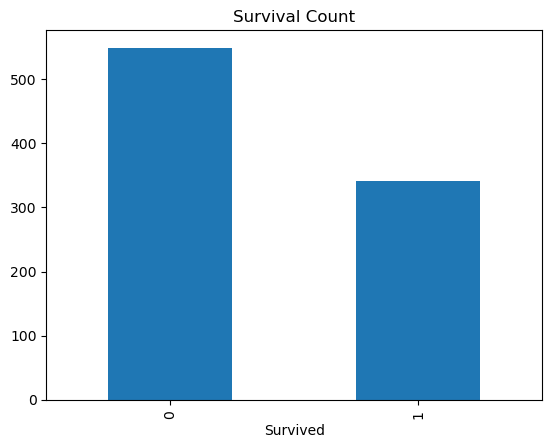

In [38]:
import matplotlib.pyplot as plt

#Survival Count
data['Survived'].value_counts().plot(kind='bar') 
plt.title("Survival Count")
plt.show()

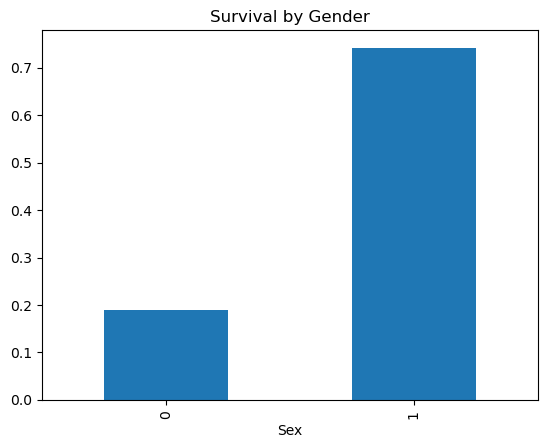

In [39]:
#Gender vs Survival
data.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Survival by Gender")
plt.show()

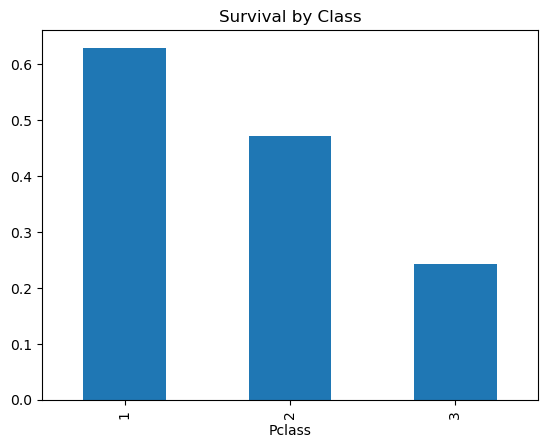

In [40]:
#Class vs Survival
data.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival by Class")
plt.show()

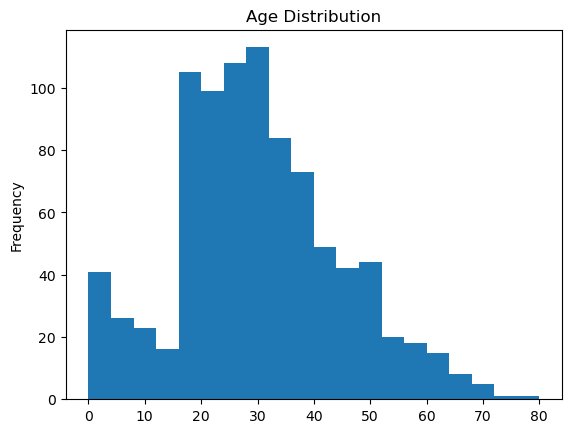

In [41]:
#Age Distribution
data['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.show()

In [ ]:
#TASK 5: Predictive Modeling 

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [42]:
#Features & Target
X = data.drop('Survived', axis=1)
y = data['Survived']

In [43]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
#Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [45]:
#Prediction
y_pred = model.predict(X_test)

In [46]:
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044692737430168
